In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
 
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]
 
drop_cols = [
    "difficulty",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]

In [2]:
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df = pd.read_csv("../data/KDDTest.txt", names=columns)

test_labels = test_df["label"].copy()

train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

train_df = train_df.drop(columns=drop_cols + ["label"])
test_df = test_df.drop(columns=drop_cols + ["label"])

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

X_train = train_df.drop(columns=["binary_label"])
y_train = train_df["binary_label"]
X_test = test_df.drop(columns=["binary_label"])
y_test = test_df["binary_label"]

neg = (y_train == 0).sum()
pos = (y_test == 0).sum()
spw = neg / pos

model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=spw, random_state=42, eval_metric="logloss", n_jobs=-1)
model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)

In [3]:
normal_idx = X_test[y_test == 0].sample(1000, random_state=42).index
attack_idx = X_test[y_test == 1].sample(1000, random_state=42).index
sample_idx = normal_idx.append(attack_idx)

X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

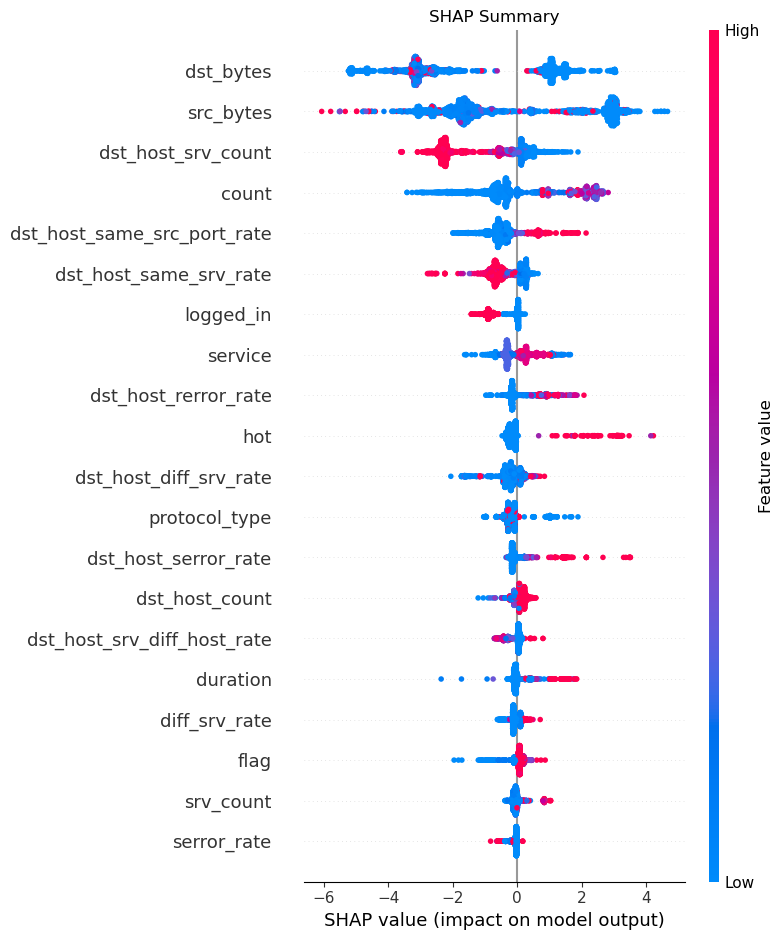

In [4]:
shap_values = explainer.shap_values(X_sample)
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title("SHAP Summary")
plt.tight_layout()

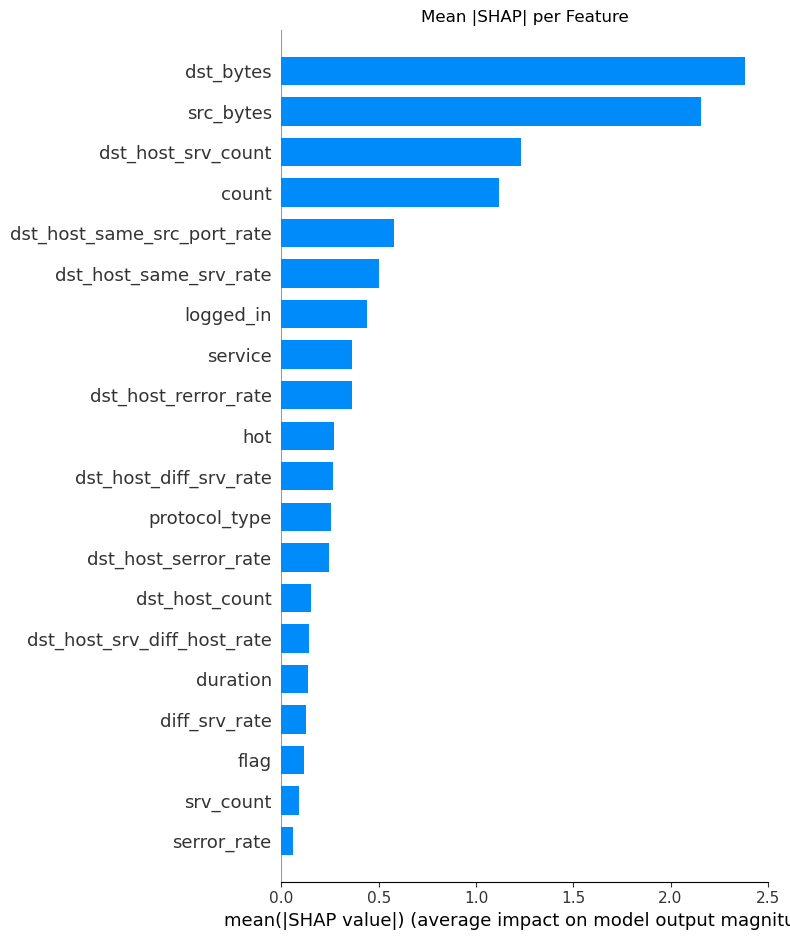

In [5]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=20)
plt.title("Mean |SHAP| per Feature")
plt.tight_layout()

<Figure size 800x500 with 0 Axes>

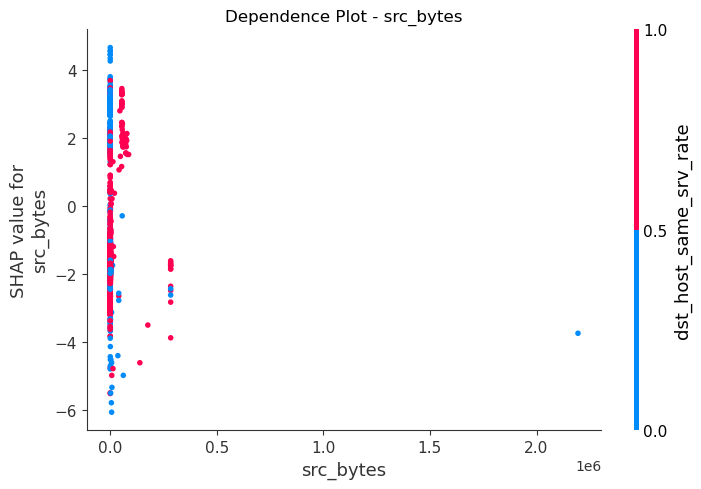

<Figure size 800x500 with 0 Axes>

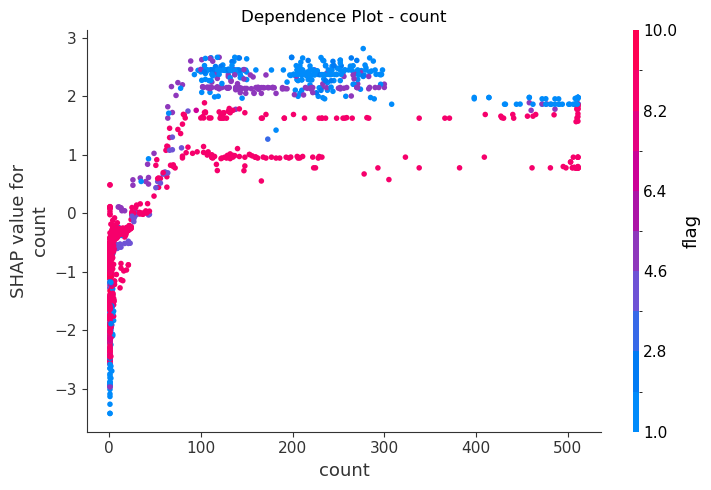

<Figure size 800x500 with 0 Axes>

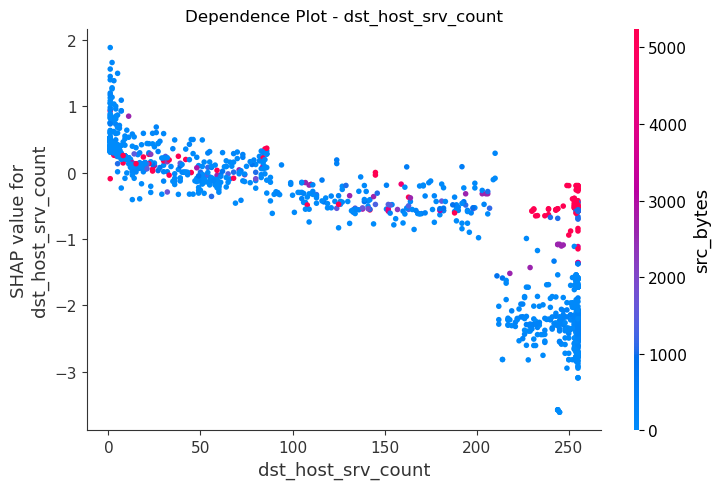

<Figure size 800x500 with 0 Axes>

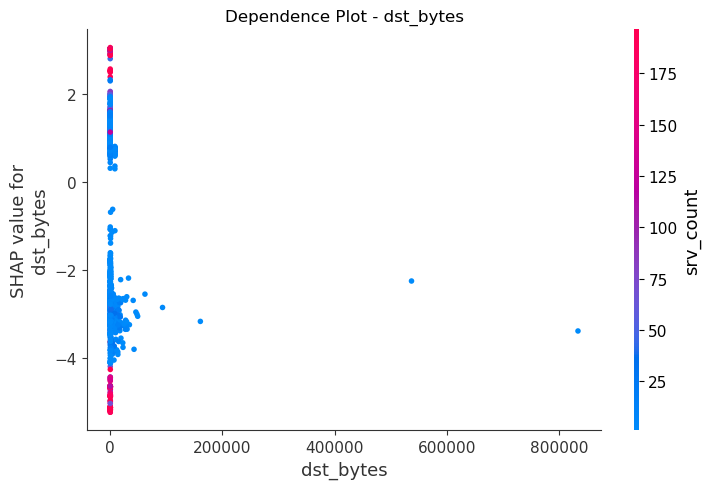

<Figure size 800x500 with 0 Axes>

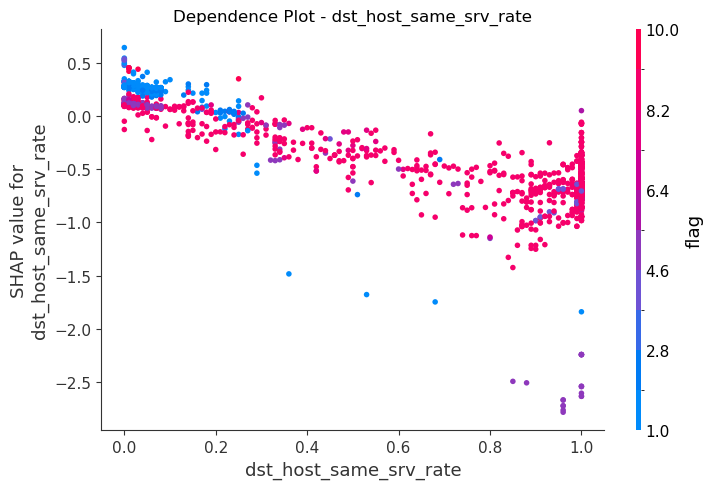

In [6]:
top_features = ["src_bytes", "count", "dst_host_srv_count",
                "dst_bytes", "dst_host_same_srv_rate"]
for feat in top_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feat, shap_values, X_sample, show=False, interaction_index="auto")
    plt.title(f"Dependence Plot - {feat}")
    plt.tight_layout()